In [2]:
import matplotlib.pyplot as plt
import numpy as np

import wandb

# Global cluster configuration mappings (used across all plots)
MARKER_POOL = {"2": "*", "4": "X", "8": "D", "16": "^"}

# Color intensity mapping for blue/red shaded plots
CLUSTER_COLOR_MAP = {
    "2": 0.2,  # Lightest shade
    "4": 0.4,  # Light-medium shade
    "8": 0.55,  # Medium-dark shade
    "16": 0.7,  # Darkest shade
}

DATASET_ORDER = {"HAR": 0, "FEMNIST": 1, "CIFAR10": 2}

# Direct color mapping for single-color plots (using viridis positions)
CLUSTER_DIRECT_COLOR_MAP = CLUSTER_COLOR_MAP

# Dataset to model mapping
DATASET_MODEL_MAP = {"HAR": "HarBox - CNN", "FEMNIST": "FEMNIST - MobileNet", "CIFAR10": "CIFAR-10 - ResNet18"}

In [3]:
api = wandb.Api(timeout=120)

In [5]:
# Collect communication cost data from the sweep
# sweep_id = "ICDCS/FedHAR/9uw01ajn"

# sweep_id = "ICDCS/FedHAR/7sim29aw"

sweep_id = "ICDCS/FedCIFAR10/gbt8maur"

print(f"Fetching sweep: {sweep_id}")
sweep = api.sweep(sweep_id)
runs = sweep.runs

# Dictionary to store run data
run_comm_costs = {}

for run in runs:
    print(f"\nProcessing run: {run.name}")
    if "2" not in run.name :
        continue

    # Initialize data structures
    rounds = []
    round_totals = {}  # {round_num: total_cost} - to accumulate costs per round across clusters
    cluster_costs = {}  # {cluster_id: [costs per round]}
    cluster_model_sizes = {}  # {cluster_id: set of unique model sizes in bits}

    # Build list of keys to fetch for up to 16 groups
    group_cost_keys = [f"CommCost/Group_{i}/Total/Combined" for i in range(16)]
    group_size_keys = [f"CommCost/Group_{i}/ModelSize/Bits" for i in range(16)]

    for i, (key_cost, key_size) in enumerate(zip(group_cost_keys, group_size_keys)):
        for row in run.scan_history(keys=["round", key_cost, key_size]):
            round_num = row["round"]
            if round_num is None:
                continue

            if round_num not in rounds:
                rounds.append(round_num)

            # Collect costs and model sizes for each cluster (up to 16)
            cost_val = row[key_cost]

            if cost_val is not None and cost_val == cost_val:  # Check for not None and not NaN
                # Accumulate cost for this round
                if round_num not in round_totals:
                    round_totals[round_num] = 0
                round_totals[round_num] += cost_val

                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(cost_val)
            else:
                if i not in cluster_costs:
                    cluster_costs[i] = []
                cluster_costs[i].append(0)

            # Collect model size in bits for each cluster

            model_size_val = row[key_size]
            if model_size_val is not None and model_size_val == model_size_val:
                if i not in cluster_model_sizes:
                    cluster_model_sizes[i] = set()
                cluster_model_sizes[i].add(model_size_val)

    # Convert round_totals dict to list ordered by rounds
    total_costs_per_round = [round_totals.get(r, 0) for r in sorted(rounds)]

    # Calculate average pruning ratio for this run
    pruning_ratios = []
    for cluster_id, sizes in cluster_model_sizes.items():
        unique_sizes = sorted(sizes)
        # Ratio of smaller to larger model size
        ratio = unique_sizes[0] / unique_sizes[-1]
        pruning_ratios.append(ratio)
        print(f"  Cluster {cluster_id}: sizes={unique_sizes}, ratio={ratio:.4f}")

    avg_ratio = np.mean(pruning_ratios)
    avg_pruning_ratio = 1 - avg_ratio
    print(f"  Average pruning ratio: {avg_pruning_ratio:.4f}")

    # Store the data
    run_comm_costs[run.name] = {
        "rounds": sorted(rounds),
        "total_costs": total_costs_per_round,
        "cluster_costs": cluster_costs,
        "cluster_model_sizes": {k: sorted(v) for k, v in cluster_model_sizes.items()},
        "avg_pruning_ratio": avg_pruning_ratio,
    }

    print(f"  Collected {len(rounds)} rounds")
    print(f"  Total clusters: {len(cluster_costs)}")

print(f"\nCollected data from {len(run_comm_costs)} runs")

Fetching sweep: ICDCS/FedCIFAR10/gbt8maur

Processing run: 4-clust-vote-4

Processing run: 4-clust-vote-3

Processing run: 4-clust-vote-2
  Cluster 0: sizes=[82301472.0, 163446880.0, 279605952.0, 369278048.0], ratio=0.2229
  Cluster 1: sizes=[82220448.0, 163446880.0, 279605952.0, 369278048.0], ratio=0.2227
  Cluster 2: sizes=[82358912.0, 163446880.0, 279605952.0, 369278048.0], ratio=0.2230
  Cluster 3: sizes=[82424224.0, 163541696.0, 279605952.0, 369278048.0], ratio=0.2232
  Average pruning ratio: 0.7771
  Collected 500 rounds
  Total clusters: 4

Processing run: 4-clust-vote-1

Collected data from 1 runs


## Old Model

In [4]:
# # parameters
# total_clients = 100
# num_clients = 10
# z_card = np.array([18, 22, 20, 40], dtype=float)
# # size in bits
# model_size = 2954224384.0 / 8
# prune_ratio = 0.4579
# # need to see based on the votes
# p = [1 / 10]

# # vectorized computations with numpy
# s_z = (z_card / total_clients) * num_clients
# extr_prob = np.divide(s_z, z_card, out=np.zeros_like(s_z))

# # compute p_z and protect against non-positive probabilities
# p_z = 1.0 - (1.0 - extr_prob * p) ** z_card

# t_before = 1.0 / p_z
# q_z = 1.0 - prune_ratio


# def cost_model(t):
#     return 2 * s_z * model_size * (np.minimum(t_before, t) + q_z * np.maximum(0, t - t_before))

## New Model

In [ ]:
# # parameters
# total_clients = 100
# num_clients = 10
# z_card = np.array([18, 22, 20, 40], dtype=float)

# # advanced params
# gamma = ...  # amout of consolidation steps
# rho = 0  # portion of cluster that tells us how many votes we need

# # size in bits
# model_size = 2954224384.0 / 8
# num_filters = 10000 / 8
# prune_ratio = np.array([0.4579])
# q_z = q_z = 1.0 - prune_ratio


# # need to see based on the votes
# p = np.array([1 / 10])


# # vectorized computations with numpy
# p_round = (num_clients / total_clients) * p
# s_z = (num_clients * z_card) / total_clients


# def v(t):
#     return s_z * p * t


# v_req = np.maximum(1, (rho * z_card))
# t_cons = v_req / (s_z * p)


# def B(t):
#     return s_z * p * num_filters * t


# def t_before(t):
#     return np.minimum(t, t_cons)


# def t_after(t):
#     return np.maximum(0, t - t_before(t))


# def g(t):
#     return 2 * s_z * model_size * (t_before(t) + q_z * t_after(t))


# 1

# def cost_model(t):
#     return 2 * s_z * model_size * (np.minimum(t_before, t) + q_z * np.maximum(0, t - t_before))

In [63]:
# parameters
total_clients = 100
num_clients = 10
z_card = np.array([18, 22, 20, 40], dtype=float)

# advanced params
gamma = 3  # amout of consolidation steps
rho = 0.5  # portion of cluster that tells us how many votes we need

# size in bits
model_size = 11539939.0 * 32
num_filters = 10000 / 8
prune_ratio = np.array([0.7771/gamma]) # 0.7771


def q(j):
    return 1.0 - (j * prune_ratio)


# need to see based on the votes
p = np.array([0.1875])


p_round = (num_clients / total_clients) * p
s_z = (num_clients * z_card) / total_clients


v_req = np.maximum(1, (rho * z_card))
delta_t = v_req / (s_z * p)


def t_j(j):
    return j * delta_t


def d(t, j, gamma):
    if j >= gamma:
        # Final stage (j = gamma): no upper bound, continues indefinitely
        return np.maximum(0, t - t_j(j))
    else:
        # Intermediate stages (j < gamma): bounded by t_j(j+1)
        return np.maximum(0, np.minimum(t, t_j(j + 1)) - t_j(j))


def g(t):
    return 2 * s_z * model_size * (sum([q(j) * d(t, j, gamma) for j in range(0, gamma + 1)]))

## Plot

Testing cost_model function...
s_z values: [1.8 2.2 2.  4. ]
model_size: 369278048.0

Test outputs:
  t=0: cost=[1.32940097e+09 1.62482341e+09 1.47711219e+09 2.95422438e+09]
  t=50: cost=[5.94200433e+10 7.26244973e+10 6.60222703e+10 1.32044541e+11]
  t=100: cost=[8.50261376e+10 1.03920835e+11 9.44734862e+10 1.88946972e+11]
  t=150: cost=[9.98423115e+10 1.22029492e+11 1.10935902e+11 2.21871803e+11]
  t=200: cost=[1.14658485e+11 1.40138149e+11 1.27398317e+11 2.54796634e+11]


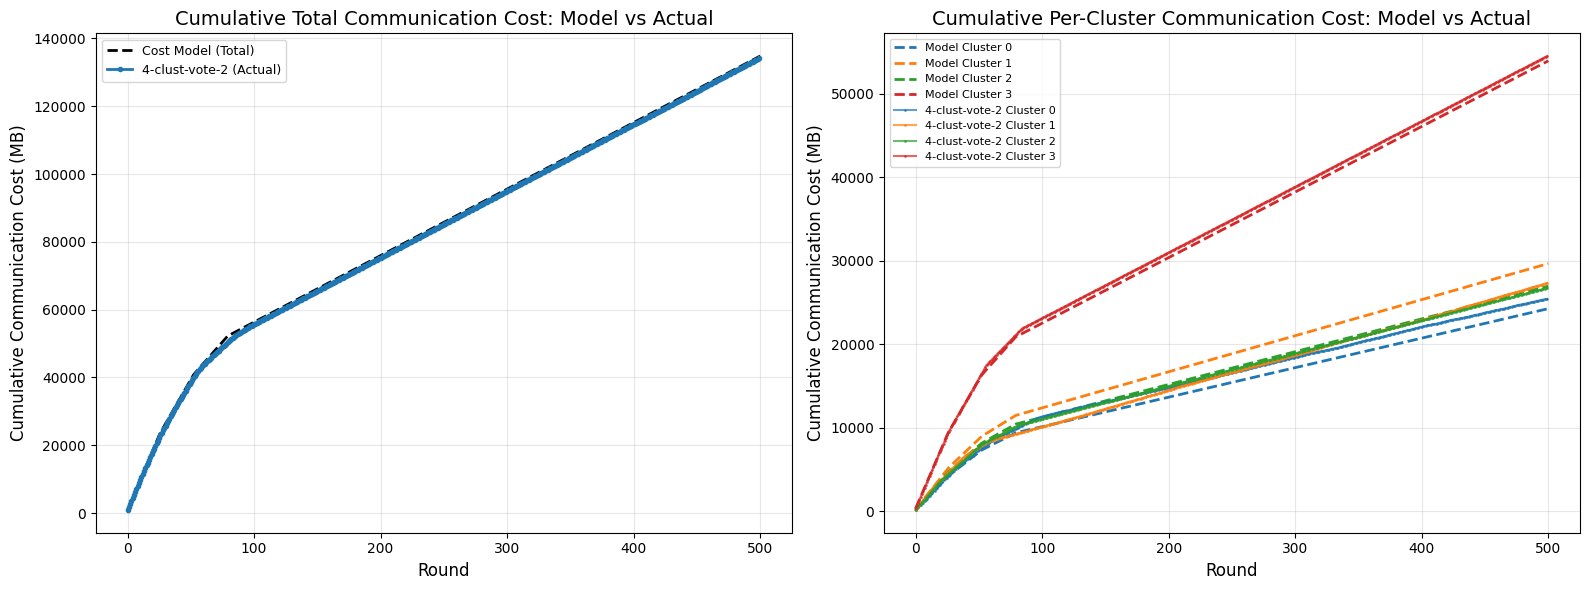


Plot generated successfully!


In [64]:
# Test and plot the cost model over time
print("Testing cost_model function...")
print(f"s_z values: {s_z}")
print(f"model_size: {model_size}")

# Test with a few sample values
test_times = [0, 50, 100, 150, 200]
print("\nTest outputs:")
for t in test_times:
    try:
        cost = g(t + 1)
        print(f"  t={t}: cost={cost}")
    except Exception as e:
        print(f"  t={t}: ERROR - {e}")

# Create time array for plotting the model
t_values = np.linspace(0, 500, 500)
model_costs = np.array([g(t + 1) for t in t_values])

# Convert model costs to MB (model already returns cumulative values)
model_costs_mb = model_costs / (8 * 1024 * 1024)

# Create figure with subplots: one for total cost, one for per-cluster costs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Communication Cost (CUMULATIVE)
ax1.set_xlabel("Round", fontsize=12)
ax1.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax1.set_title("Cumulative Total Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative total cost (sum across groups) - already cumulative from model
total_model_cost = model_costs_mb.sum(axis=1)
ax1.plot(t_values, total_model_cost, label="Cost Model (Total)", linewidth=2, linestyle="--", color="black")

# Plot actual run total costs (CUMULATIVE)
for run_name, run_data in run_comm_costs.items():
    rounds = run_data["rounds"]
    total_costs = np.cumsum(run_data["total_costs"]) / (8 * 1024 * 1024)  # Cumulative and convert to MB
    ax1.plot(rounds, total_costs, label=f"{run_name} (Actual)", linewidth=2, marker="o", markersize=3)

ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Per-Cluster Communication Cost (CUMULATIVE)
ax2.set_xlabel("Round", fontsize=12)
ax2.set_ylabel("Cumulative Communication Cost (MB)", fontsize=12)
ax2.set_title("Cumulative Per-Cluster Communication Cost: Model vs Actual", fontsize=14)

# Plot model cumulative costs per group - already cumulative from model
for i in range(len(z_card)):
    ax2.plot(t_values, model_costs_mb[:, i], label=f"Model Cluster {i}", linewidth=2, linestyle="--")

# Plot actual cluster costs from runs (CUMULATIVE)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for run_name, run_data in run_comm_costs.items():
    rounds = run_data["rounds"]
    cluster_costs = run_data["cluster_costs"]

    for cluster_id, costs in cluster_costs.items():
        cumulative_costs = np.cumsum(costs) / (8 * 1024 * 1024)  # Cumulative and convert to MB
        if (cumulative_costs == 0).all():
            continue
        ax2.plot(
            rounds,
            cumulative_costs[:500],
            label=f"{run_name} Cluster {cluster_id}",
            linewidth=1.5,
            marker=".",
            markersize=2,
            color=colors[cluster_id % 10],
            alpha=0.7,
        )

ax2.legend(loc="best", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPlot generated successfully!")